**Fintech 545 – Quantitative Risk Management**  
Course Notebook
Felipe J.  

Prof. Dominic J. Pazzula

### Week 1 and 2 - Univariate Statistics and Multivariate Regression

---
**Fitting a Predetermined Distribution** to data  
* Assignments 7.1, 7.2
------

In [97]:
# Fitting a predetermined Distribution to data
import numpy as np
import pandas as pd
import scipy.stats as stats

# import data
data = pd.read_csv('data/test7_2.csv')

# Fit t-distribution using MLE (standard method in scipy)
# scipy.stats.t.fit returns (df, loc, scale) where df=nu, loc=mu, scale=sigma
fit_distrib = stats.t.fit(data['x1'].values) # t-distribution in this case (taking input=data)

results = pd.DataFrame(columns=['nu', 'mu', 'sigma'])
results['nu'] = [fit_distrib[0]]     # Note the brackets!
results['mu'] = [fit_distrib[1]]     # Makes it a list
results['sigma'] = [fit_distrib[2]]  # Creates 1 row

print(results.to_string(index=False)) # print w/o index
results                               # print w/ index

      nu      mu    sigma
6.336867 0.04594 0.045443


,nu,mu,sigma
0,6.336867,0.04594,0.045443


---
**Performing a T-distribution Regression**  
* Assignment 7.3
---

**T-Distribution Regression - Mathematical Framework**

Model Specification:


* We model the relationship between response $y$ and predictors $\mathbf{x} = [x_1, x_2, x_3]$ as: $y_i = \alpha + \beta_1 x_{i1} + \beta_2 x_{i2} + \beta_3 x_{i3} + \varepsilon_i$

* where errors follow a centered t-distribution: $\varepsilon_i \sim t(0, \sigma, \nu)$ 

* In matrix notation: $\mathbf{y} = \alpha\mathbf{1} + \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}$

**Maximum Likelihood Estimation**

* The PDF of a t-distribution with location $\mu=0$, scale $\sigma$, and degrees of freedom $\nu$ is: $f(\varepsilon|\sigma,\nu) = \frac{\Gamma(\frac{\nu+1}{2})}{\Gamma(\frac{\nu}{2})\sqrt{\nu\pi\sigma^2}} \left(1 + \frac{\varepsilon^2}{\nu\sigma^2}\right)^{-\frac{\nu+1}{2}}$

* For computational convenience, we standardize: $z = \varepsilon/\sigma \sim t(0, 1, \nu)$ where $\varepsilon = x_i - \mu$

* Using the change of variables formula, the density becomes: $f(\varepsilon|\sigma,\nu) = \frac{1}{\sigma} f_{\text{std}}\left(\frac{\varepsilon}{\sigma}\bigg|\nu\right)$

**Log-Likelihood Function**

The log-likelihood for $n$ observations is:

$$\log L(\alpha, \boldsymbol{\beta}, \sigma, \nu | \mathbf{y}) = \sum_{i=1}^n \left[\log f_{\text{std}}\left(\frac{\varepsilon_i}{\sigma}\bigg|\nu\right) - \log(\sigma)\right]$$

where $\varepsilon_i = y_i - \alpha - \mathbf{x}_i^\top\boldsymbol{\beta}$, Note that this is just rearranging the regression equation formula

**In code:** `np.sum(stats.t.logpdf(residuals/sigma, df=nu) - np.log(sigma))`

**Optimization**

We maximize $\log L$ (equivalently, minimize $-\log L$) over parameters $\theta = (\sigma, \nu, \alpha, \beta_1, \beta_2, \beta_3)$: $\hat{\theta} = \arg\max_{\theta} \log L(\theta | \mathbf{y})$

* **Initialization:** Use OLS to get starting values for $(\alpha, \boldsymbol{\beta})$, set $\sigma_0 = \text{SD}(\text{residuals})$, $\nu_0 = 5$ (this is starting one, it will get optimized)
* * $\nu = 1$ is extremely fat tails, $\nu = 30$ is approximately normal. So this is a middle ground

* **Method:** Nelder-Mead simplex algorithm (derivative-free numerical optimization)

**Key Matrix Operations**

* Adding intercept: $[\mathbf{1} | \mathbf{X}]$ creates $(n \times 4)$ design matrix

* Predictions: $\hat{\mathbf{y}} = \alpha\mathbf{1} + \mathbf{X}\boldsymbol{\beta}$ computed as `alpha + X @ beta`

* Residuals: $\boldsymbol{\varepsilon} = \mathbf{y} - \hat{\mathbf{y}}$

**Why T-Distribution?:** Standard regression assumes $\varepsilon_i \sim N(0, \sigma^2)$ with thin tails. The t-distribution with finite $\nu$ exhibits **excess kurtosis**, making it robust to outliers and appropriate for financial data with fat-tailed returns.

In [161]:
# T distribution Regression (fit a T-regression)
# y = α + β₁x₁ + β₂x₂ + β₃x₃ + ε, where ε ~ t(0, σ, ν)
# We're saying: "y depends linearly on x1, x2, x3, plus some t-distributed noise."

import pandas as pd
import numpy as np
from scipy import stats
from scipy.optimize import minimize
import statsmodels.api as sm

data = pd.read_csv('data/test7_3.csv')
X = data[['x1', 'x2', 'x3']].values
y = data['y'].values

def neg_log_lik(params):
    sigma, nu, alpha, beta = params[0], params[1], params[2], params[3:6]
    
    if sigma <= 0 or nu <= 0:
        return 1e10
    
    resid = y - (alpha + X @ beta)
         
    # Log-likelihood for t-distribution, formula reference: 
    # log L = Σ log [ t_pdf((y_i - y_pred)/sigma; nu) / sigma ]
    return -np.sum(stats.t.logpdf(resid/sigma, df=nu) - np.log(sigma)) # t-dist pdf evaluated at x_i = ε (but scaled by sigma)

# Initialize with OLS (initial parameters for MLE optimization)
# recall, this will perfrom y = α + β₁x₁ + β₂x₂ + β₃x₃ + ε and will implicityly assume that ε ~ N(0, σ^2)
ols = sm.OLS(y, sm.add_constant(X)).fit()
init = [ols.resid.std(), 5.0] + ols.params.tolist() # sigma, nu, alpha, beta_i   # (params of our lin regression)

# Now obtain best params for t-regression; ε ~ t(0, σ, ν)
result = minimize(neg_log_lik, init, method='Nelder-Mead')
sigma, nu, alpha, b1, b2, b3 = result.x

print(f"mu\tsigma\tnu\tAlpha\tB1\tB2\tB3")
print(f"{0.0}\t{sigma}\t{nu}\t{alpha}\t{b1}\t{b2}\t{b3}")

mu	sigma	nu	Alpha	B1	B2	B3
0.0	0.04854805644350006	4.598266361204714	0.04263393808530718	0.9748808222335805	2.0411931163471095	3.1548055952795107


OLS: "Draw the best line assuming all points have equal reliability"
T-regression: "Draw the best line assuming outliers are less reliable (downweight them)"

The t-regression line will be slightly different (more robust to outliers).
In summary:
* OLS step: Get a good starting guess (fast, assumes normal errors)
* Optimization step: Fine-tune ALL parameters to fit t-distribution model (slow, but more robust)    

The final parameters (α, β₁, β₂, β₃) from the optimization are not the same as from OLS - they're adjusted to account for the fat-tailed error distribution.


---
**Calculating Returns:** arithmetic vs log
* Assignments 6.1, 6.2  
---

**Returns Calculations**

Concept:  
Prices are non-stationary (they trend up/down over time and violate modeling assumptions). We must transform prices into returns which are stationary and suitable for statistical modeling. *Suppose $r_t$ is the return off an asset at time $t$.*

**Three types:**
1. **Classical Brownian motion:** $ P_t = P_{t-1} + r_t  $ (rarely used)
2. **Arithmetic returns:** $ P_t = P_{t-1} · (1 + r_t)  $ (portfolio math)
3. **Log returns:** $P_t = P_{t-1} · e^{r_t}$ (time series analysis)

**Mathematics**

**Arithmetic (Simple) Return:**
```r_t = (P_t - P_{t-1}) / P_{t-1}```
- Intuitive: "I gained/lost X% today"
- **Additive across assets:** Portfolio return = weighted average of asset returns
- **NOT additive across time:** 10% + 10% ≠ 20% compound return

**Log (Geometric) Return:** ```r_t = ln(P_t / P_{t-1}) = ln(P_t) - ln(P_{t-1})```
- **Additive across time:** Sum of daily log returns = total period return
- Approximates arithmetic return for small r
- Theoretically cleaner (normally distributed under certain conditions)

**When to use which?**
- **Arithmetic:** Cross-sectional analysis (comparing returns across stocks on same day), portfolio calculations
- **Log:** Time series analysis (modeling returns over time), multi-period compounding

**Key property:**
If daily log returns satisfy $r_t \sim \mathcal{N}(\mu,\sigma^2)$, then the $T$-day log return is the sum $R_T=\sum_{t=1}^T r_t$.  
Since sums of independent normal variables are normal, $R_T \sim \mathcal{N}(T\mu,\;T\sigma^2)$.  
Thus the mean scales with $T$ and the variance scales with $T$ (standard deviation scales with $\sqrt{T}$).

In [ ]:
df = pd.read_csv('data/test6.csv')

# calculate Arithmetic returns for each column except Date
returns_arthm_df = df.copy()
for col in returns_arthm_df.columns[1:]: # skip Date column
    returns_arthm_df[col] = returns_arthm_df[col].pct_change()  # note first row will be NaN as it has no previous data
     
returns_arthm_df = returns_arthm_df.iloc[1:] # skipping first row from all columns in data (deleting NaN row)
                                 # alternatively, returns_df.dropna()

In [ ]:
# Calculate Log Returns 
returns_log_df = df.copy()
for col in returns_log_df.columns[1:]: # skip Date column
    returns_log_df[col] = np.log(returns_log_df[col]).diff() # Alternatively, returns_df[col] = np.log(df[col] / df[col].shift(1))
                                                             # this option allows us to control shift(n=#) parameter.
returns_log_df.dropna()                                                          

### Week 3 - Financial Data and Monte Carlo 

---
**CoVariance and Correlation**: Skippin Rows or Pairwise for Missing Data  
* Assignments 1.1, 1.2, 1.3, 1.4
---

**What are Covariance & Correlation?**

**Covariance** measures how two variables move together:
$$\text{Cov}(X,Y) = E[(X - \mu_X)(Y - \mu_Y)] = \frac{1}{n}\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})$$

- Positive → move together (both up or both down)
- Negative → move opposite
- Units matter!: Cov(stock A in \$, stock B in \$) has units of dollars², ($\$^2)$

**Correlation** is standardized covariance (unit-free):
$$\rho_{X,Y} = \frac{\text{Cov}(X,Y)}{\sigma_X \sigma_Y} \in [-1, 1]$$

- Always between -1 and +1
- Easier to interpret: $\rho = 0.8$ means "strong positive relationship"

**The Missing Data Problem**:  
Real financial data has gaps (holidays, delisted stocks, data errors). How do we calculate covariance when data is missing?

**Method 1: Listwise (Skip Missing Rows)** → `df.dropna().cov()`
- Delete any row where **ANY** variable is missing
- **Pro:** Guarantees valid (PSD) covariance matrix
- **Con:** Wastes data (if 1 stock missing → throw out entire day!)

**Method 2: Pairwise** → `df.cov(min_periods=1)`
- For each pair $(X_i, X_j)$, use all days where **BOTH** have data
- Different pairs use different subsets of data
- **Pro:** Uses maximum available information
- **Con:** May produce non-PSD matrix (can't do Cholesky!)

**The `min_periods` Parameter**
```python
df.cov(min_periods=1)  # Pairwise: use all available pairs
```

`min_periods=1` means "use at least 1 overlapping observation" for each covariance calculation. This enables **pairwise deletion** where Cov(A,B) might use 100 days while Cov(A,C) uses only 50 days.  
**`min_periods=1`** means: For each pair of columns, pandas automatically finds all rows where **both** have data (non-NaN), and if there's at least 1 such row, it calculates covariance using only those overlapping rows.  
Different pairs use different subsets of rows → Cov(A,B) might use days {2,4}, Cov(A,C) uses days {1,2,4,5}, etc.

**Why does pairwise break PSD?** Because the covariances aren't calculated on a consistent sample, the matrix can have negative eigenvalues (mathematically impossible for a true covariance matrix).

In [214]:
# Calculate Covar(X_i), skipping missing data
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm

data = pd.read_csv('data/test1.csv') # missing values appear as NaN
data = data.dropna()                 # dropping missing vals
covar = data.cov()

In [ ]:
# Calculate Corr(X_i), skipping missing data
data = pd.read_csv('data/test1.csv') # missing values appear as NaN
data.dropna()
corr = data.corr()

In [ ]:
# Calculate Covar(X_i), pairwise approach for missing data
# pairwise correlation - uses all available data for each pair
data = pd.read_csv('data/test1.csv') # missing values appear as NaN
covar = data.cov(min_periods=1)

In [222]:
# Calculate Corr(X_i), pariwise approach for missing data
# pairwise correlation - uses all available data for each pair
data = pd.read_csv('data/test1.csv') # missing values appear as NaN
corr = data.corr(min_periods=1)

---
**Exponentially Weighted CoVariance (and Variance) and Correlation**
* Assignments 2.1, 2.2, 2.3
---

**Exponentially Weighted Covariance - Why & How**  
Markets change regime. Volatility from 2 years ago is **irrelevant** to today's risk. EW covariance gives you a **time-adaptive risk estimate**:

- **Problem:** Equal-weight covariance treats calm 2020 data same as volatile 2024 data
- **Solution:** Weight recent data heavily → covariance reflects **current market conditions**

**Use case:** You're a risk manager. Market just crashed. Do you want your VaR calculation to include calm data from 6 months ago equally? **No.** You want recent volatility to dominate.


**The Confusing Line:**
```python
weighted_mean = (df * weights[:, np.newaxis]).sum(axis=0)
```
What `weights[:, np.newaxis]` does: Reshapes weights from `(n,)` to `(n, 1)` so it broadcasts across columns.
```python
# weights shape: (100,)  ← 100 days
# df shape: (100, 5)     ← 100 days × 5 stocks

# weights[:, np.newaxis] shape: (100, 1)
# Broadcasting: (100, 1) * (100, 5) → (100, 5)
# Each column multiplied by same weights vector
```

In plain English: Multiply each stock's return on each day by that day's weight, then sum across days → weighted mean for each stock.

**The Manual Covariance Computation Loop:**
```python
for i in range(n_vars):
    for j in range(n_vars):
        dev_i = df.iloc[:, i] - weighted_mean.iloc[i]
        dev_j = df.iloc[:, j] - weighted_mean.iloc[j]
        cov_matrix[i, j] = (weights * dev_i * dev_j).sum()
```

**Formula:**
$$\text{Cov}_w(X, Y) = \sum_{t=1}^n w_t (x_t - \mu_X)(y_t - \mu_Y)$$

**Why no divide by n?** Weights already sum to 1! We normalized them: `weights = weights / weights.sum()`. So the weighted sum **is** the weighted average.


**Can't We Just Call `.cov()`?**
Short answer: Pandas **does** have this built-in:
```python
import pandas as pd

df = pd.read_csv('data/test2.csv')

# That's it - one line!
result = df.ewm(alpha=1-0.97).cov().iloc[-len(df.columns):]

expected = pd.read_csv('data/testout_2_1.csv')
print(result.values)
print(expected.values)
```

**Bottom Line:**
- EW covariance = regular covariance formula but with exponentially decaying weights instead of equal weights
- Weights sum to 1 → no need to divide by n
- Manual implementation for learning; pandas has `.ewm()` for production use

In [252]:
# Compute EW (Exponentially Weighted) Covariance & Correlation, lambda=0.97
import numpy as np
import pandas as pd

df = pd.read_csv('data/test2.csv')

# exponentially weighted covariance with lambda decay
def ew_covar_and_corr(data, lambda_decay=0.94):
    n = len(df) # rows (observations) or data points
    
    # calculate exponential weights (most recent gets highest weight)
    weights = np.array([(1 - lambda_decay) * (lambda_decay ** i) for i in range(n)]) # weights formula:  wᵢ = (1-λ)·λⁱ⁻¹
    weights = weights[::-1]  # reverse so most recent is last
    weights = weights / weights.sum()  # normalize to sum to 1
    
    # calculate weighted mean
    weighted_mean = (df * weights[:, np.newaxis]).sum(axis=0)  # broadcast weights, Explicit: "multiply each column by weights"
    
    # calculate weighted covariance manually
    n_vars = len(df.columns)
    cov_matrix = np.zeros((n_vars, n_vars)) # square matrix sixe (cols*cols)
    
    # NOW COVAR: covar(X, Y) formula implementation
    # formula: above
    for i in range(n_vars):
        for j in range(n_vars):
            dev_i = df.iloc[:, i] - weighted_mean.iloc[i] 
            dev_j = df.iloc[:, j] - weighted_mean.iloc[j]
            cov_matrix[i, j] = (weights * dev_i * dev_j).sum() # see above formula
            
    # NOW CORRELATION: convert covariance to correlation
    # formula: Corr(X, Y) = Cov(X, Y)/(sigma_x*sigma_y)
    std_devs = np.sqrt(np.diag(cov_matrix)) # the diagonals of the CoVar matrix are the the Variances (sigma^2) of each individual variable!
    corr_matrix = cov_matrix / np.outer(std_devs, std_devs)
    
    ew_covar = pd.DataFrame(cov_matrix, columns=df.columns, index=df.columns)
    ew_corr = pd.DataFrame(corr_matrix, columns=df.columns, index=df.columns),
    return ew_covar, ew_corr

print(ew_covar_and_corr(data)[0]) # EW CoVariance
print(ew_covar_and_corr(data)[1]) # EW Correlation

          x1        x2        x3        x4        x5
x1  0.699681  0.074914  0.139033  0.099977  0.061392
x2  0.074914  1.115739 -0.071513  0.197847 -0.485224
x3  0.139033 -0.071513  0.764491  0.160562  0.092658
x4  0.099977  0.197847  0.160562  0.857855  0.114928
x5  0.061392 -0.485224  0.092658  0.114928  1.077469
(          x1        x2        x3        x4        x5
x1  1.000000  0.084787  0.190100  0.129045  0.070706
x2  0.084787  1.000000 -0.077432  0.202228 -0.442546
x3  0.190100 -0.077432  1.000000  0.198267  0.102093
x4  0.129045  0.202228  0.198267  1.000000  0.119541
x5  0.070706 -0.442546  0.102093  0.119541  1.000000,)


**Equivalently, we could implement this using the following method**:


In [273]:
# Faster Automatic Approach
import pandas as pd

df = pd.read_csv('data/test2.csv')

# That's it - one line!
result1 = df.ewm(alpha=1-0.97).cov().iloc[-len(df.columns):]
result2 = df.ewm(alpha=1-0.94).corr().iloc[-len(df.columns):]

print(result1)
result2

# Why .iloc[-len(df.columns):]? 
# Because .ewm().cov() returns covariance at every time step (shape: 200×5 for 40 days). 
# We only want the last 5 rows = final covariance matrix at time t=39.

             x1        x2        x3        x4        x5
39 x1  0.873091  0.123503  0.184313  0.086361  0.057030
   x2  0.123503  1.110707  0.025394  0.118442 -0.441995
   x3  0.184313  0.025394  0.757684  0.137621  0.071023
   x4  0.086361  0.118442  0.137621  0.892950  0.116039
   x5  0.057030 -0.441995  0.071023  0.116039  1.170727


x1        x2        x3        x4        x5
39 x1  1.000000  0.084787  0.190100  0.129045  0.070706
   x2  0.084787  1.000000 -0.077432  0.202228 -0.442546
   x3  0.190100 -0.077432  1.000000  0.198267  0.102093
   x4  0.129045  0.202228  0.198267  1.000000  0.119541
   x5  0.070706 -0.442546  0.102093  0.119541  1.000000

In [271]:
# BONUS: hybrid approach (manual)
import numpy as np
import pandas as pd

# hybrid: EW variance (lambda=0.97) and EW correlation (lambda=0.94)
def ew_cov_hybrid(filepath, lambda_var=0.97, lambda_corr=0.94):
    '''
    the output is ONE covariance matrix.
    Here's the flow:

    Calculate EW variances (diagonal) using λ=0.97 → get σ²ᵢ for each stock
    Calculate EW correlation matrix using λ=0.94 → get ρᵢⱼ
    Combine them into one covariance matrix using: Cov(i,j) = ρᵢⱼ · σᵢ · σⱼ

    The output is the hybrid covariance matrix - it has:

    Diagonal (variances) from λ=0.97
    Off-diagonal (covariances) constructed from λ=0.94 correlations × λ=0.97 std devs

    So testout_2_3.csv is ONE 5×5 covariance matrix that's a blend of both lambdas.
    '''
    df = pd.read_csv(filepath)
    n = len(df)
    
    # weights for variance calculation (lambda=0.97)
    weights_var = np.array([(1 - lambda_var) * (lambda_var ** i) for i in range(n)])
    weights_var = weights_var[::-1]
    weights_var = weights_var / weights_var.sum()
    
    # weights for correlation calculation (lambda=0.94)
    weights_corr = np.array([(1 - lambda_corr) * (lambda_corr ** i) for i in range(n)])
    weights_corr = weights_corr[::-1]
    weights_corr = weights_corr / weights_corr.sum()
    
    # calculate weighted mean for variance
    weighted_mean_var = (df * weights_var[:, np.newaxis]).sum(axis=0)
    
    # calculate weighted mean for correlation
    weighted_mean_corr = (df * weights_corr[:, np.newaxis]).sum(axis=0)
    
    # calculate variances using lambda=0.97
    n_vars = len(df.columns)
    variances = np.zeros(n_vars)
    for i in range(n_vars):
        dev_i = df.iloc[:, i] - weighted_mean_var.iloc[i]
        variances[i] = (weights_var * dev_i ** 2).sum()
    
    # calculate correlation matrix using lambda=0.94
    corr_matrix = np.zeros((n_vars, n_vars))
    for i in range(n_vars):
        for j in range(n_vars):
            dev_i = df.iloc[:, i] - weighted_mean_corr.iloc[i]
            dev_j = df.iloc[:, j] - weighted_mean_corr.iloc[j]
            cov_ij = (weights_corr * dev_i * dev_j).sum()
            std_i = np.sqrt((weights_corr * dev_i ** 2).sum())
            std_j = np.sqrt((weights_corr * dev_j ** 2).sum())
            corr_matrix[i, j] = cov_ij / (std_i * std_j)
    
    # combine: Cov = D * Corr * D where D is diagonal std dev matrix
    std_devs = np.sqrt(variances)
    cov_matrix = np.outer(std_devs, std_devs) * corr_matrix
    
    return pd.DataFrame(cov_matrix, columns=df.columns, index=df.columns)

# BONUS: Hybrid appoach automatic
import pandas as pd
import numpy as np

df = pd.read_csv('data/test2.csv')

# Get variances with λ=0.97
variances = df.ewm(alpha=1-0.97).var().iloc[-1]  # last row = final variances
std_devs = np.sqrt(variances)

# Get correlation with λ=0.94
corr = df.ewm(alpha=1-0.94).corr().iloc[-len(df.columns):]  # final corr matrix

# Combine: Cov = D × Corr × D (where D = diag(std_devs))
cov = corr * np.outer(std_devs, std_devs)

# print(cov)

**Further Reading on Exponetially Weighted CoVar and Corr**    

**Concept**: Exponentially Weighted Covariance 

Data from 2 years ago is less relevant than data from last week. Equal weighting treats all observations the same. Give more weight to recent observations, less to old ones. This is called exponentially weighted covariance.

**Mathematics**  
**Standard covariance** (equal weights):  
$$σ² = \frac{1}n Σ(xᵢ - μ)²$$
**Exponentially weighted covariance:**  
$$ σₜ² = λ·σₜ₋₁² + (1-λ)·(xₜ₋₁ - μ)² $$

Where λ (lambda) is the **decay factor**:
- λ = 0.94 → aggressive decay (only ~20 days matter)
- λ = 0.97 → moderate decay (RiskMetrics recommended)
- λ = 0.99 → slow decay (~100 days matter)

**Weight formula for observation i periods ago:**
$$ wᵢ = (1-λ)·λⁱ⁻¹ $$

**Key insight:** This is equivalent to GARCH(1,1) model with α=(1-λ) and β=λ.

**Visual intuition**
```
λ=0.75: [0.25, 0.19, 0.14, 0.11, ...] → steep drop
λ=0.94: [0.06, 0.06, 0.05, 0.05, ...] → moderate
λ=0.97: [0.03, 0.03, 0.03, 0.03, ...] → gradual
```

---
**PD and PSD Matrices**: Fixing non-PSD matrices (Rebonato-Jäckel & Higham)
* Assignments: 3.1, 3.2, 3.3, 3.4
---

**The Problem**  
Pairwise covariance (from missing data) can produce **non-PSD matrices** with negative eigenvalues. This breaks Cholesky decomposition → can't simulate!

**Why it matters:** You need PSD matrices to:
- Do Monte Carlo simulation (need Cholesky root)
- Calculate portfolio risk (need valid covariance)
- Avoid mathematically impossible scenarios

**Two Methods to Fix**:

**3.1 & 3.2: Rebonato-Jäckel (Fast, Spectral)**   
**Concept:** Zero out every negative eigenvalues, rescale to preserve the diagonal.  

**Math:**
1. Eigenvalue decomposition: $C = S \Lambda S^T$
2. Fix eigenvalues: $\lambda'_i = \max(\lambda_i, 0)$
3. Rescale to keep diagonal = 1 (or original variances)
4. Reconstruct: $C_{fixed} = B B^T$ where $B = T \cdot S \cdot \sqrt{\Lambda'}$  

**Code:**
```python
vals, vecs = np.linalg.eigh(matrix)
vals = np.maximum(vals, 0)  # Zero negatives
# Rescale + reconstruct (see full code)
```

**3.3 & 3.4: Higham's Algorithm (Slow, More Accurate)**  
**Concept:** Iteratively project between two constraints until convergence.  

**Math:** Alternate between:
- **Project to PSD:** Zero negative eigenvalues
- **Project to correlation:** Set diagonal = 1

Repeat until $\|Y_k - Y_{k-1}\| < \epsilon$

**Code:**
```python
for iteration in range(max_iterations):
    X = project_to_PSD(Y - Delta_S)  # Fix eigenvalues
    Y = project_to_correlation(X)     # Fix diagonal = 1
    # Check convergence
```
**Bottom Line**  
Pairwise → breaks matrix → fix with spectral methods → can now use Cholesky → simulate!

In [291]:
# Near_PSD for CoVar and Corr matrices (Spectral) ------------- Method 1 ------------
import numpy as np
import pandas as pd
from numpy.linalg import eigh

input_matrix = pd.read_csv('data/testout_1.3.csv')

# fix non-PSD matrix using Rebonato-Jackel method
def near_psd(matrix, epsilon=0.0):
    n = matrix.shape[0]
    
    # check if it's a correlation matrix (diagonal = 1) or covariance
    invSD = None
    out = matrix.copy()
    
    # if covariance, convert to correlation
    if not np.allclose(np.diag(out), 1.0):
        invSD = np.diag(1.0 / np.sqrt(np.diag(out)))
        out = invSD @ out @ invSD
    
    # eigenvalue decomposition
    vals, vecs = eigh(out)
    
    # set negative eigenvalues to epsilon (or 0)
    vals = np.maximum(vals, epsilon)
    
    # reconstruct with scaling matrix T
    T = 1.0 / (vecs ** 2 @ vals)
    T = np.diag(np.sqrt(T))
    
    B = T @ vecs @ np.diag(np.sqrt(vals))
    out = B @ B.T
    
    # convert back to covariance if needed
    if invSD is not None:
        invSD = np.diag(1.0 / np.diag(invSD))
        out = invSD @ out @ invSD
    
    return out

# read the non-PSD matrix from 1.3
# read the non-PSD correlation matrix from 1.4
# matrix = input_matrix.values

# fix it
result = near_psd(input_matrix)
result

array([[ 1.17398583, -0.61798867, -0.284559  , -0.06515152, -0.68828687],
       [-0.61798867,  1.3181973 ,  0.01709196,  0.44569555,  0.13917594],
       [-0.284559  ,  0.01709196,  0.91810185,  0.35414666,  0.24605561],
       [-0.06515152,  0.44569555,  0.35414666,  0.89476398, -0.21871734],
       [-0.68828687,  0.13917594,  0.24605561, -0.21871734,  0.52260731]])

**Rebonato-Jäckel Method - Detailed**: (further reading)  

**The Math**
**Goal:** Find $B$ such that $C_{fixed} = BB^T$ is PSD with correct diagonal.

**Steps:**
1. Eigenvalue decomposition: $C = S\Lambda S^T$
2. Zero negatives: $\Lambda' = \max(\Lambda, 0)$
3. Build scaling matrix $T$ to fix diagonal
4. Reconstruct: $B = T^{1/2} \cdot S \cdot \Lambda'^{1/2}$


**The Code**  
n1.  

```python
def near_psd(matrix, epsilon=0.0):
    n = matrix.shape[0]
    invSD = None
    out = matrix.copy()
```
**Setup:** Copy input, prepare to track if it's covariance vs correlation.  
n2.


```python
    # If covariance (diag ≠ 1), convert to correlation first
    if not np.allclose(np.diag(out), 1.0):
        invSD = np.diag(1.0 / np.sqrt(np.diag(out)))  # 1/σᵢ for each variable
        out = invSD @ out @ invSD                       # C → R (correlation)
```
**Why?** Algorithm works on correlation. If input is covariance:
- Extract std devs: $\sigma_i = \sqrt{C_{ii}}$
- Convert to correlation: $R = D^{-1} C D^{-1}$ where $D = \text{diag}(\sigma)$  
 
n3.
```python
    vals, vecs = eigh(out)  # Eigenvalue decomposition
    vals = np.maximum(vals, epsilon)  # Zero out negatives
```
**Core fix:** $C = S\Lambda S^T$, then $\Lambda' = \max(\Lambda, 0)$

**Why this works:** Negative eigenvalues → not PSD. Setting them to 0 → PSD!

n4.  
```python
    T = 1.0 / (vecs ** 2 @ vals)  # Scaling factors
    T = np.diag(np.sqrt(T))
```
**The tricky part:** After zeroing eigenvalues, diagonal may not be 1 anymore.

**Math:** We need $T$ such that $\text{diag}(TSS^T\Lambda' S^T S T) = I$

This simplifies to: $T_{ii} = 1 / \sqrt{\sum_j s_{ij}^2 \lambda'_j}$

**What it does:** Rescale so diagonal = 1 (for correlation).

n5.   
```python
    B = T @ vecs @ np.diag(np.sqrt(vals))
    out = B @ B.T
```
**Reconstruct:** $C_{fixed} = BB^T$ where $B = T \cdot S \cdot \sqrt{\Lambda'}$

**Why this form?** Guarantees:
- $C_{fixed}$ is PSD (product of matrix with itself)
- Diagonal = 1 (thanks to $T$)

n6.  
```python
    # Convert back to covariance if needed
    if invSD is not None:
        invSD = np.diag(1.0 / np.diag(invSD))  # Get original σᵢ back
        out = invSD @ out @ invSD               # R → C
    
    return out
```
**Final step:** If we started with covariance, scale back: $C = D R D$


**Key Insight**
The algorithm doesn't just zero eigenvalues - it also **rescales** to preserve the diagonal (variances). That's what $T$ does. Without $T$, your variances would be wrong after fixing eigenvalues.

**Bottom line:** Eigenvalue decomposition → fix eigenvalues → rescale → reconstruct → done!

In [288]:
# Near_PSD for CoVar and Corr matrices (Higham) ------------- Method 2 ------------

import numpy as np
import pandas as pd
from numpy.linalg import eigh

input_matrix = pd.read_csv('data/testout_1.4.csv')

# Higham's algorithm for nearest PSD matrix
def higham_psd(matrix, max_iterations=100, tol=1e-9):
    n = matrix.shape[0]
    
    # check if covariance or correlation
    invSD = None
    out = matrix.copy()
    
    if not np.allclose(np.diag(out), 1.0):
        invSD = np.diag(1.0 / np.sqrt(np.diag(out)))
        out = invSD @ out @ invSD
    
    # initialize
    Y = out.copy()
    Delta_S = np.zeros((n, n))
    prev_norm = np.inf
    
    for iteration in range(max_iterations):
        # project to PSD (fix negative eigenvalues)
        R = Y - Delta_S
        vals, vecs = eigh(R)
        vals = np.maximum(vals, 0)  # set negative to 0
        X = vecs @ np.diag(vals) @ vecs.T
        
        Delta_S = X - R
        
        # project to unit diagonal (set diagonal to 1)
        Y = X.copy()
        np.fill_diagonal(Y, 1.0)
        
        # check convergence
        norm = np.linalg.norm(Y - out, 'fro')
        if abs(norm - prev_norm) < tol:
            break
        prev_norm = norm
    
    out = Y
    
    # convert back to covariance if needed
    if invSD is not None:
        invSD = np.diag(1.0 / np.diag(invSD))
        out = invSD @ out @ invSD
    
    return out


# fix using Higham
result = higham_psd(matrix)
result

array([[ 1.        , -0.48319932, -0.24178663, -0.06776693, -0.71476123],
       [-0.48319932,  1.        ,  0.01544631,  0.40565982,  0.17828625],
       [-0.24178663,  0.01544631,  1.        ,  0.48824985,  0.33624763],
       [-0.06776693,  0.40565982,  0.48824985,  1.        , -0.32213624],
       [-0.71476123,  0.17828625,  0.33624763, -0.32213624,  1.        ]])

**Higham's Algorithm - The Details and Intuition**: (further reading)  

**The Core Idea**  
Think of it as **ping-ponging between two broken versions** until you find something that's not broken.

You have two constraints:
1. **Be PSD** (all eigenvalues ≥ 0)
2. **Have diagonal = 1** (be a valid correlation matrix)

Your broken matrix violates both. Higham says: "Fix one, then fix the other, repeat until both are satisfied."

---

**The Math (High Level)**  

Two projection operators:

**$P_S$: Project to PSD space**
- Take eigenvalue decomposition
- Set negative eigenvalues to 0
- Reconstruct

**$P_U$: Project to unit diagonal**
- Just set diagonal = 1
- Keep everything else

**Algorithm:** Alternate projections until convergence
$$Y_0 = C, \quad \Delta S_0 = 0$$
$$\text{Repeat: } X_k = P_S(Y_{k-1} - \Delta S_{k-1}), \quad Y_k = P_U(X_k)$$


**The Code - Line by Line**  
```python
Y = out.copy()
Delta_S = np.zeros((n, n))
prev_norm = np.inf
```
**Setup:** 
- $Y$ = current estimate (starts as broken matrix)
- $\Delta S$ = tracks "how much we moved" in PSD projection
- `prev_norm` = for convergence check

---
```python
for iteration in range(max_iterations):
    R = Y - Delta_S  # Undo previous PSD movement
```
**Why $R = Y - \Delta S$?**

We're doing **Dykstra's correction** - a clever trick to make alternating projections converge to the *nearest* matrix (not just *a* valid matrix).

Think of $\Delta S$ as "memory" of what the PSD projection did, so we can partially undo it before projecting again.

---
```python
    vals, vecs = eigh(R)
    vals = np.maximum(vals, 0)
    X = vecs @ np.diag(vals) @ vecs.T
```
**$P_S$: Project to PSD**
- Decompose: $R = S\Lambda S^T$
- Fix: $\Lambda' = \max(\Lambda, 0)$
- Reconstruct: $X = S\Lambda' S^T$

Now $X$ is PSD! ✓ But diagonal might not be 1. ✗

---
```python
    Delta_S = X - R  # Track how much we moved
```
**Update memory:** Remember the "correction" we applied in the PSD step.

---
```python
    Y = X.copy()
    np.fill_diagonal(Y, 1.0)
```
**$P_U$: Project to correlation**
- Take $X$ (which is PSD)
- Force diagonal = 1

Now diagonal is 1! ✓ But might have broken PSD again. ✗

---
```python
    norm = np.linalg.norm(Y - out, 'fro')
    if abs(norm - prev_norm) < tol:
        break
    prev_norm = norm
```
**Check convergence:** Is $Y$ changing? If it stopped moving → we found the solution!

**Frobenius norm:** $\|A\|_F = \sqrt{\sum_{i,j} a_{ij}^2}$ (like L2 distance for matrices)

---

**Why Does This Work?**  

**Magic of alternating projections:** If you keep bouncing between two constraints, you eventually land at a point that satisfies *both* (in the limit).

**Dykstra's correction** ($\Delta S$): Makes it converge to the *closest* valid matrix (minimizes Frobenius distance).

---

**Visual Intuition**  
```
        [PSD matrices]
             ↗  ↘
    Start → ? → ? → Converge!
             ↖  ↙
     [Correlation matrices]
```

Each iteration pulls you toward one constraint, then the other. Eventually you reach the intersection.

---

**Key Differences from Rebonato-Jäckel**  

| | Rebonato-Jäckel | Higham |
|---|---|---|
| **Method** | One-shot spectral fix | Iterative projections |
| **Speed** | Fast (one pass) | Slow (many iterations) |
| **Accuracy** | Good | Best (provably nearest) |
| **Output** | *A* valid matrix | *The nearest* valid matrix |

---

**Bottom Line**  

Higham = "Keep fixing PSD, then fixing diagonal, until both stay fixed." It's slower but finds the mathematically optimal solution (closest valid matrix to your broken one).

**Production-Grade (Succint) PSD Fixing Functions**: (further reading)

These functions handle both covariance and correlation matrices automatically and match assignments 3.1-3.4 exactly.
```python
import numpy as np
from numpy.linalg import eigh

def near_psd(matrix):
    """Rebonato-Jäckel with rescaling (preserves diagonal exactly)"""
    invSD = None
    out = matrix.copy()
    
    if not np.allclose(np.diag(out), 1.0):
        invSD = np.diag(1.0 / np.sqrt(np.diag(out)))
        out = invSD @ out @ invSD
    
    vals, vecs = eigh(out)
    vals = np.maximum(vals, 0)
    
    # Rescaling to preserve diagonal
    T = np.diag(np.sqrt(1.0 / (vecs ** 2 @ vals)))
    B = T @ vecs @ np.diag(np.sqrt(vals))
    out = B @ B.T
    
    if invSD is not None:
        invSD = np.diag(1.0 / np.diag(invSD))
        out = invSD @ out @ invSD
    
    return out

def higham_psd(matrix, max_iter=100, tol=1e-9):
    """Higham's algorithm (exact nearest PSD matrix)"""
    invSD = None
    out = matrix.copy()
    
    if not np.allclose(np.diag(out), 1.0):
        invSD = np.diag(1.0 / np.sqrt(np.diag(out)))
        out = invSD @ out @ invSD
    
    Y = out.copy()
    Delta_S = np.zeros_like(out)
    prev_norm = np.inf
    
    for _ in range(max_iter):
        R = Y - Delta_S
        vals, vecs = eigh(R)
        vals = np.maximum(vals, 0)
        X = vecs @ np.diag(vals) @ vecs.T
        Delta_S = X - R
        Y = X.copy()
        np.fill_diagonal(Y, 1.0)
        
        norm = np.linalg.norm(Y - out, 'fro')
        if abs(norm - prev_norm) < tol:
            break
        prev_norm = norm
    
    if invSD is not None:
        invSD = np.diag(1.0 / np.diag(invSD))
        Y = invSD @ Y @ invSD
    
    return Y
```

**Usage:**
```python
fixed_matrix = near_psd(broken_matrix)      # Fast, good for most cases
fixed_matrix = higham_psd(broken_matrix)    # Slower, provably nearest
```

**Key features:**
- Auto-detects covariance vs correlation
- Preserves diagonal exactly (with rescaling)
- Works for any symmetric matrix
- Matches testout files for assignments 3.1-3.4

---
**Cholesky Decomposition for PSD Matrices**
* Assignments: 4.1
---

**Cholesky Decomposition for PSD Matrices**

**The Problem**
Standard `np.linalg.cholesky()` **fails** on PSD matrices (those with zero eigenvalues). We need a version that handles zeros gracefully.

**What is Cholesky?**:  
"Square root" of a matrix: Find lower triangular $L$ such that $\Sigma = LL^T$

$$\Sigma = \begin{bmatrix} 4 & 2 \\ 2 & 5 \end{bmatrix} = \begin{bmatrix} 2 & 0 \\ 1 & 2.24 \end{bmatrix} \begin{bmatrix} 2 & 1 \\ 0 & 2.24 \end{bmatrix}$$

**Why We Need It**:  
**Monte Carlo simulation:** To generate correlated random variables
$$X = L \cdot Z + \mu$$
where $Z \sim N(0, I)$ (independent standard normals)

**The Algorithm**   
Column-by-column construction:  
**For column $j$:**
1. **Diagonal:** $L_{jj} = \sqrt{\Sigma_{jj} - \sum_{k=1}^{j-1} L_{jk}^2}$
2. **Below diagonal:** $L_{ij} = \frac{1}{L_{jj}}(\Sigma_{ij} - \sum_{k=1}^{j-1} L_{ik}L_{jk})$ for $i > j$

**PSD handling:** If $L_{jj}$ would be zero (or negative due to floating point error), set entire column $j$ to zero.

**The Code**:
```python
import numpy as np

def chol_psd(matrix, epsilon=1e-8):
    """
    Cholesky for PSD matrices (handles zero eigenvalues).
    Builds L column-by-column such that Σ = L @ L.T
    """
    n = matrix.shape[0] # rows
    L = np.zeros((n, n))
    
    for j in range(n):  # Build column j
        
        # Diagonal: L[j,j] = sqrt(Σ[j,j] - sum_of_squares_so_far)
        s = np.dot(L[j, :j], L[j, :j]) if j > 0 else 0.0  # Sum of L[j,k]² for k<j
        temp = matrix[j, j] - s  # What's inside sqrt
        
        # PSD handling: if temp ≈ 0 (zero eigenvalue), set column to zero
        if -epsilon <= temp <= epsilon:
            temp = 0.0
        if temp == 0.0:
            continue  # Leave column as zeros, move to next
        
        L[j, j] = np.sqrt(temp)
        
        # Below diagonal: L[i,j] = (Σ[i,j] - dot_product) / L[j,j]
        inv = 1.0 / L[j, j]
        for i in range(j + 1, n):
            s = np.dot(L[i, :j], L[j, :j])  # Dot product of what we've built
            L[i, j] = (matrix[i, j] - s) * inv
    
    return L
```

**Key Difference from `np.linalg.cholesky()`**:
After fixing a matrix with near_psd() or higham_psd(), you might still have zero eigenvalues (PSD, not PD). Standard np.linalg.cholesky() would crash. Our chol_psd() works fine

**Usage**
```python
# This would crash with np.linalg.cholesky()
Sigma_psd = np.array([[1, 1], [1, 1]])  # rank deficient

L_cov = chol_psd(cov_matrix_broken)
L_corr = chol_psd(corr_matrix_broken)
# Returns: [[1, 0], [1, 0]]  ← second column is zero (zero eigenvalue)
```
**Verification:** $LL^T$ should equal $\Sigma$ (within tolerance for PSD matrices).

In [298]:
def chol_psd(matrix, epsilon=1e-8):
    """
    Cholesky for PSD matrices (handles zero eigenvalues).
    Builds L column-by-column such that Σ = L @ L.T
    """
    n = matrix.shape[0] # rows
    L = np.zeros((n, n))
    
    for j in range(n):  # Build column j
        
        # Diagonal: L[j,j] = sqrt(Σ[j,j] - sum_of_squares_so_far)
        s = np.dot(L[j, :j], L[j, :j]) if j > 0 else 0.0  # Sum of L[j,k]² for k<j
        temp = matrix[j, j] - s  # What's inside sqrt
        
        # PSD handling: if temp ≈ 0 (zero eigenvalue), set column to zero
        if -epsilon <= temp <= epsilon:
            temp = 0.0
        if temp == 0.0:
            continue  # Leave column as zeros, move to next
        
        L[j, j] = np.sqrt(temp)
        
        # Below diagonal: L[i,j] = (Σ[i,j] - dot_product) / L[j,j]
        inv = 1.0 / L[j, j]
        for i in range(j + 1, n):
            s = np.dot(L[i, :j], L[j, :j])  # Dot product of what we've built
            L[i, j] = (matrix[i, j] - s) * inv
    
    return L

If we knew matrix was certainly PD:

In [ ]:
# if we knew our matrix was PD:
import numpy as np
import pandas as pd

# INPUT: testout_3.1.csv (already PD after fixing)
input_matrix = pd.read_csv('data/testout_3.1.csv')
matrix = input_matrix.values

# One line!
result = np.linalg.cholesky(matrix)

True


### Week 4 – Value at Risk (VaR)

---
**Monte Carlo simulations (PD, PSD, PCA)**
* Assignments: 5.1-5.5
---

**Monte Carlo Simulation**  

**The Big Picture**  
* **Goal:** Simulate correlated random variables from a covariance matrix, verify simulation recovers the input.
* **Why?** This is the foundation of risk simulation - generate thousands of possible future scenarios based on historical correlation structure.

**5.1: Normal Simulation (PD Input)**  
**Concept**  
Standard multivariate normal simulation. Matrix is positive definite (all eigenvalues > 0), so standard Cholesky works.  
**Math**  
Generate correlated normals:
$$X = L \cdot Z + \mu$$

Where:
- $X \sim N(\mu, \Sigma)$ (what we want)
- $Z \sim N(0, I)$ (independent standard normals)
- $L$ = Cholesky root where $\Sigma = LL^T$

**Verification:** Calculate $\text{Cov}(X)$ from simulated data → should ≈ input $\Sigma$

In [294]:
import numpy as np
import pandas as pd

cov = pd.read_csv('data/test5_1.csv').values

# Cholesky decomposition
L = np.linalg.cholesky(cov)  # Works because PD

# Generate 100k independent normals
np.random.seed(0)
Z = np.random.normal(0, 1, size=(cov.shape[0], 100000))

# Transform to correlated (assume μ=0)
X = (L @ Z).T

# Verify: simulated covariance ≈ input
result = np.cov(X.T)
expected = pd.read_csv('data/testout_5.1.csv').values

print(np.allclose(result, expected, atol=1e-3))  # True

True


**5.2: Normal Simulation (PSD Input)**

**Concept**  
Matrix has zero eigenvalues (PSD, not PD). Standard `np.linalg.cholesky()` would crash. Use `chol_psd()`.  
**Math**    
Same as 5.1, but:
- Some eigenvalues = 0 → some columns of $L$ = 0
- Those dimensions contribute nothing to simulation (perfectly predictable from others)

In [300]:
### **Code**
import numpy as np
import pandas as pd

cov = pd.read_csv('data/test5_2.csv').values

# Use PSD-safe Cholesky
L = chol_psd(cov)  # Handles zeros

np.random.seed(0)
Z = np.random.normal(0, 1, size=(cov.shape[0], 100000))
X = (L @ Z).T

result = np.cov(X.T)
expected = pd.read_csv('data/testout_5.2.csv').values

print(np.allclose(result, expected, atol=1e-2))

True


**Difference:** `chol_psd()` instead of `np.linalg.cholesky()`

**5.3: Non-PSD → Near PSD → Simulate**:

**Concept**
Input has **negative** eigenvalues (from pairwise covariance). Fix with Rebonato-Jäckel, then simulate.

**Workflow**
1. Input is broken (non-PSD)
2. Fix: `near_psd()` → zeroes negative eigenvalues
3. Decompose: `chol_psd()` on fixed matrix
4. Simulate
5. Verify simulated covariance ≈ **fixed** matrix (not original!)

In [303]:
import numpy as np
import pandas as pd

cov = pd.read_csv('data/test5_3.csv').values

# Fix non-PSD matrix
fixed = near_psd(cov) # now PSD

# Cholesky on fixed matrix
L = chol_psd(fixed)

np.random.seed(0)
Z = np.random.normal(0, 1, size=(cov.shape[0], 100000))
X = (L @ Z).T

result = np.cov(X.T)
expected = pd.read_csv('data/testout_5.3.csv').values

print(np.allclose(result, expected, atol=1e-3))

True


**Key:** Fix → Simulate → Verify against **fixed** matrix.

**5.4: Non-PSD → Higham → Simulate**

**Concept**:
Same as 5.3 but use **Higham's algorithm** instead of Rebonato-Jäckel.

**Difference**
- Rebonato-Jäckel (5.3): Fast, good approximation
- Higham (5.4): Slower, finds *nearest* PSD matrix

In [ ]:
import numpy as np
import pandas as pd

cov = pd.read_csv('data/test5_3.csv').values  # Same input as 5.3

# Fix with Higham instead
fixed = higham_psd(cov)

L = chol_psd(fixed)

np.random.seed(0)
Z = np.random.normal(0, 1, size=(cov.shape[0], 100000))
X = (L @ Z).T

result = np.cov(X.T)
expected = pd.read_csv('data/testout_5_4.csv').values

print(np.allclose(result, expected, atol=1e-3))


A complete implementation, (altho algorithms already written above, but for convenience):

In [304]:
import numpy as np
import pandas as pd
from numpy.linalg import eigh

# Higham's algorithm to find nearest PSD matrix
def higham_psd(matrix, max_iterations=100, tol=1e-9):
    n = matrix.shape[0]
    invSD = None
    out = matrix.copy()
    if not np.allclose(np.diag(out), 1.0):
        invSD = np.diag(1.0 / np.sqrt(np.diag(out)))
        out = invSD @ out @ invSD
    Y = out.copy()
    Delta_S = np.zeros((n, n))
    prev_norm = np.inf
    for _ in range(max_iterations):
        R = Y - Delta_S
        vals, vecs = eigh(R)
        vals = np.maximum(vals, 0)
        X = vecs @ np.diag(vals) @ vecs.T
        Delta_S = X - R
        Y = X.copy()
        np.fill_diagonal(Y, 1.0)
        norm = np.linalg.norm(Y - out, 'fro')
        if abs(norm - prev_norm) < tol:
            break
        prev_norm = norm
    out = Y
    if invSD is not None:
        invSD = np.diag(1.0 / np.diag(invSD))
        out = invSD @ out @ invSD
    return out

# simulate using higham_psd then chol_psd
# read input covariance matrix

def chol_psd(matrix):
    n = matrix.shape[0]
    root = np.zeros((n, n))
    for j in range(n):
        s = np.dot(root[j, :j], root[j, :j]) if j > 0 else 0.0
        temp = matrix[j, j] - s
        if 0 >= temp >= -1e-8:
            temp = 0.0
        root[j, j] = np.sqrt(temp) if temp > 0 else 0.0
        if root[j, j] != 0.0:
            ir = 1.0 / root[j, j]
            for i in range(j + 1, n):
                s = np.dot(root[i, :j], root[j, :j])
                root[i, j] = (matrix[i, j] - s) * ir
    return root


np.random.seed(0)
cov = pd.read_csv('data/test5_3.csv').values
cols = pd.read_csv('data/test5_3.csv').columns

# fix with Higham then simulate
fixed = higham_psd(cov)
L = chol_psd(fixed)
Z = np.random.normal(0, 1, size=(cov.shape[0], 100000))
sim = (L @ Z).T

result = pd.DataFrame(np.cov(sim.T), columns=cols)
expected = pd.read_csv('data/testout_5.4.csv')
print(np.allclose(result.values, expected.values, atol=1e-3))

True


**5.5: PCA Simulation (Dimensionality Reduction)**

**Concept**  
* **Problem:** 100 correlated variables → need 100 random numbers per simulation → slow!
* **Solution:** Only simulate the **most important** dimensions using PCA.

**Math** :  
**Eigenvalue decomposition:**
$$\Sigma = S \Lambda S^T$$

Where:
- $S$ = eigenvectors (principal components)
- $\Lambda$ = eigenvalues (variance explained by each component)

**Variance explained by first $k$ components:**
$$\frac{\lambda_1 + \lambda_2 + ... + \lambda_k}{\lambda_1 + \lambda_2 + ... + \lambda_n}$$

**Simulation with only $k$ components:**
$$X = S_k \sqrt{\Lambda_k} Z$$

Where $S_k$ and $\Lambda_k$ are top $k$ components explaining ≥99% variance.

In [310]:
import numpy as np
import pandas as pd
from numpy.linalg import eigh

cov = pd.read_csv('data/test5_2.csv').values

# Eigenvalue decomposition
vals, vecs = eigh(cov)

# Sort largest to smallest
idx = vals.argsort()[::-1]
vals = vals[idx]
vecs = vecs[:, idx]

# Keep only positive eigenvalues
pos = vals > 1e-8
vals = vals[pos]
vecs = vecs[:, pos]

# How many components for 99% variance?
total_var = vals.sum()
cumulative = np.cumsum(vals) / total_var
n_components = np.searchsorted(cumulative, 0.99) + 1

print(f"Need {n_components} components (out of {len(vals)}) for 99% variance")

# Keep only top components
vals = vals[:n_components]
vecs = vecs[:, :n_components]

# Build transformation: B = S_k × sqrt(Λ_k)
# simulate using only top components
B = vecs @ np.diag(np.sqrt(vals))

# Simulate with FEWER random numbers!
np.random.seed(0)
Z = np.random.normal(0, 1, size=(n_components, 100000))  # Only n_components, not n!
X = (B @ Z).T

result = np.cov(X.T)
expected = pd.read_csv('data/testout_5.5.csv').values

print(np.allclose(result, expected, atol=1e-2))

Need 2 components (out of 4) for 99% variance
True


**Key Benefit**  
If 3 components explain 99% of variance in 100 variables:
- Standard: Generate 100 random numbers per sim
- PCA: Generate only 3 random numbers per sim → **33x faster!**  

**Summary Table**  

| Assignment | Input | Fix Method | Key Point |
|------------|-------|------------|-----------|
| 5.1 | PD | None | Standard Cholesky works |
| 5.2 | PSD | None | Use `chol_psd()` for zeros |
| 5.3 | Non-PSD | Rebonato-Jäckel | Fix → Simulate |
| 5.4 | Non-PSD | Higham | Different fix → Different output |
| 5.5 | PSD | None | PCA for speed (fewer dimensions) |

**Key Concepts**:  

1. **Simulation workflow:** Cov → Cholesky → Transform independent normals
2. **PSD handling:** Use `chol_psd()` when zeros present
3. **Fixing broken matrices:** near_psd or Higham before simulation
4. **PCA:** Simulate only important dimensions for efficiency
5. **Verification:** Simulated covariance should recover input (within Monte Carlo error)

### Week 5 - Advanced VaR and Expected Shortfall.pdf

---
**Var from Normal Distribution, T Distribution, and from Simulation**
* Assignments 8.1, 8.2, 8.
---


**8.1-8.3: Value at Risk (VaR)**

**8.1: VaR from Normal Distribution**
* **Concept**: Calculate VaR assuming returns follow a normal distribution.
* **VaR = Minimum loss at α confidence level** (5th percentile for 95% confidence)

**Math**  
For normal distribution:
$$\text{VaR}_\alpha = -(\mu + \sigma \cdot z_\alpha)$$

Where:
- $\mu$ = mean return
- $\sigma$ = standard deviation
- $z_\alpha$ = `norm.ppf(0.05)` = -1.645 for 95% confidence

**Two versions:**
- **VaR Absolute:** Total loss from zero
- **VaR Diff from Mean:** Loss relative to expected return

**Code**
```python
import numpy as np
import pandas as pd
from scipy import stats

data = pd.read_csv('data/test7_1.csv')
x = data['x1'].values

# Fit normal distribution
mu = np.mean(x)
sigma = np.std(x, ddof=1)

# VaR at 95% confidence (α = 0.05)
alpha = 0.05
z_alpha = stats.norm.ppf(alpha)  # -1.645

var_absolute = -(mu + sigma * z_alpha)
var_diff_mean = -sigma * z_alpha

result = pd.DataFrame({
    'VaR Absolute': [var_absolute],
    'VaR Diff from Mean': [var_diff_mean]
})
```

**Key:** Simple formula - just quantile of normal distribution.


**8.2: VaR from T-Distribution**
* **Concept**: Fit t-distribution (heavier tails) and calculate VaR using t-distribution quantile.
* **Why t-distribution?**: Financial returns have extreme events more often than normal predicts.

**Math**
For t-distribution:
$$\text{VaR}_\alpha = -(mu + \sigma \cdot t_{\alpha, \nu})$$

Where:
- $\nu$ = degrees of freedom (fitted parameter)
- $t_{\alpha, \nu}$ = `t.ppf(α, ν)` (t-distribution quantile)

**Code**
```python
import numpy as np
import pandas as pd
from scipy import stats

data = pd.read_csv('data/test7_2.csv')
x = data['x1'].values

# Fit t-distribution
params = stats.t.fit(x)
nu, mu, scale = params

# VaR at 95% confidence
alpha = 0.05
t_alpha = stats.t.ppf(alpha, nu)

var_absolute = -(mu + scale * t_alpha)
var_diff_mean = -scale * t_alpha

result = pd.DataFrame({
    'VaR Absolute': [var_absolute],
    'VaR Diff from Mean': [var_diff_mean]
})
```

**Key difference from 8.1:** Must fit df parameter (ν), uses t-quantile instead of z-quantile.



**8.3: VaR from Simulation**
* **Concept**: Instead of using formulas, **simulate many scenarios** and calculate VaR empirically as the 5th percentile.
* **Why?**: Works for ANY distribution, not just normal/t. More flexible.

**Math**

**Algorithm:**
1. Fit distribution to data (normal, t, or any other)
2. Simulate 100,000 draws from fitted distribution
3. VaR = 5th percentile of simulated returns (with negative sign)

$$\text{VaR}_\alpha = -\text{percentile}(\text{simulated returns}, \alpha \times 100)$$

**Code**
```python
import numpy as np
import pandas as pd
from scipy import stats

np.random.seed(0)
data = pd.read_csv('data/test7_2.csv')
x = data['x1'].values

# Fit t-distribution
params = stats.t.fit(x)
nu, mu, scale = params

# Simulate 100k draws
sim = stats.t.rvs(nu, mu, scale, size=100000)

# VaR = 5th percentile (with negative sign)
alpha = 0.05
var_absolute = -np.percentile(sim, alpha * 100)

# For VaR diff from mean, simulate with μ=0
sim_zero_mean = stats.t.rvs(nu, 0, scale, size=100000)
var_diff_mean = -np.percentile(sim_zero_mean, alpha * 100)

result = pd.DataFrame({
    'VaR Absolute': [var_absolute],
    'VaR Diff from Mean': [var_diff_mean]
})
```

**Key:** Empirical approach - just take percentile of simulated distribution.

---

**Comparison: 8.1 vs 8.2 vs 8.3**

| Assignment | Distribution | Method | Speed | When to Use |
|------------|-------------|--------|-------|-------------|
| 8.1 | Normal | Formula | Fastest | If returns are normally distributed |
| 8.2 | T-distribution | Formula | Fast | If returns have fat tails |
| 8.3 | T-distribution | Simulation | Slower | Validate formulas, complex distributions |

---

**Key Differences: VaR vs ES**

| | VaR | ES |
|---|-----|-----|
| **Question** | What is the loss threshold I won’t exceed with X% confidence? | What's my average loss provided that VaR is exceeded (Worst X% cases)? |
| **Math** | 5th percentile | Average of worst 5% |
| **Formula (Normal)** | $-(\mu + \sigma z_\alpha)$ | $-\mu - \sigma \frac{\phi(z_\alpha)}{\alpha}$ |
| **Coherent?** | No (not sub-additive) | Yes (sub-additive) |
| **Popularity** | Widely used (regulatory) | Gaining popularity |

**Bottom line:** VaR tells you the threshold, ES tells you the expected loss beyond that threshold.

---
**ES from Normal Distribution, T-Distribution, and Simulation**
* Assignments: 8.4,8.5,8.6
---

**Week 5: Expected Shortfall & Copulas (8.4-8.6, 9.1)**

**8.4: ES from Normal Distribution**
* **Concept**: Calculate Expected Shortfall assuming returns follow a normal distribution.
* **ES = Average loss in the worst α% of cases**
For normal: ES has a closed-form formula (no simulation needed).

**Math**
$$\text{ES}_\alpha = -\mu - \sigma \cdot \frac{\phi(z_\alpha)}{\alpha}$$

Where:
- $\mu$ = mean
- $\sigma$ = standard deviation
- $z_\alpha$ = `norm.ppf(α)` (e.g., -1.645 for α=0.05)
- $\phi(z_\alpha)$ = `norm.pdf(z_\alpha)` (PDF at that point)

**Two versions:**
- **ES Absolute:** $\text{ES} = -\mu + \sigma \cdot \frac{\phi(z_\alpha)}{\alpha}$
- **ES Diff from Mean:** $\text{ES} = \sigma \cdot \frac{\phi(z_\alpha)}{\alpha}$

**Code**
```python
import numpy as np
import pandas as pd
from scipy import stats

data = pd.read_csv('data/test7_1.csv')
x = data['x1'].values

# Fit normal distribution
mu = np.mean(x)
sigma = np.std(x, ddof=1)

# ES at 95% confidence
alpha = 0.05
z_alpha = stats.norm.ppf(alpha)  # -1.645
phi_z = stats.norm.pdf(z_alpha)   # PDF at that point

# ES formulas
es_diff_mean = sigma * phi_z / alpha
es_absolute = -mu + sigma * phi_z / alpha

result = pd.DataFrame({
    'ES Absolute': [es_absolute], 
    'ES Diff from Mean': [es_diff_mean]
})
```
**Key:** Closed-form formula, no simulation needed.



**8.5: ES from T-Distribution**
* **Concept**: Fit t-distribution to data (heavier tails than normal), calculate ES using t-distribution formula.
* **Why t-distribution?**: Financial returns have fat tails - t-distribution models this better than normal.

**Math**

For t-distribution:
$$\text{ES} = -\mu - \sigma \cdot \frac{\nu + t_\alpha^2}{\nu - 1} \cdot \frac{f(t_\alpha)}{\alpha}$$

Where:
- $\nu$ = degrees of freedom (df)
- $t_\alpha$ = `t.ppf(α, ν)` 
- $f(t_\alpha)$ = `t.pdf(t_α, ν)`

**Code**
```python
import numpy as np
import pandas as pd
from scipy import stats

data = pd.read_csv('data/test7_2.csv')
x = data['x1'].values

# Fit t-distribution (don't force mean=0)
params = stats.t.fit(x)
nu, mu, scale = params

# ES formula for t-distribution
alpha = 0.05
t_alpha = stats.t.ppf(alpha, nu)
pdf_t_alpha = stats.t.pdf(t_alpha, nu)

es_diff_mean = scale * (nu + t_alpha**2) / (nu - 1) * pdf_t_alpha / alpha
es_absolute = -mu + es_diff_mean

result = pd.DataFrame({
    'ES Absolute': [es_absolute],
    'ES Diff from Mean': [es_diff_mean]
})
```

**Key:** Must fit df (ν) parameter, formula accounts for heavier tails.



**8.6: ES from Simulation**
* **Concept**: Instead of using formulas, **simulate 100k scenarios** from fitted t-distribution and calculate ES empirically.
* **Why?**: Validates the formula approach, and works for ANY distribution (not just normal/t).

**Math**
**Algorithm:**
1. Fit t-distribution to get (ν, μ, σ)
2. Simulate 100k draws from fitted distribution
3. Calculate VaR = 5th percentile
4. ES = average of all losses ≤ VaR

$$\text{ES} = -\frac{1}{n_{\text{tail}}} \sum_{x_i \leq -\text{VaR}} x_i$$

**Code**
```python
import numpy as np
import pandas as pd
from scipy import stats

np.random.seed(0)
data = pd.read_csv('data/test7_2.csv')
x = data['x1'].values

# Fit t-distribution
params = stats.t.fit(x)
nu, mu, scale = params

# Simulate 100k draws
sim = stats.t.rvs(nu, mu, scale, size=100000)

# Calculate ES
alpha = 0.05
var_sim = -np.percentile(sim, alpha * 100)

# ES = average of losses beyond VaR
losses_beyond_var = sim[sim <= -var_sim]
es_absolute = -losses_beyond_var.mean()

# For ES diff from mean, simulate with μ=0
sim_zero_mean = stats.t.rvs(nu, 0, scale, size=100000)
threshold_zero = np.percentile(sim_zero_mean, alpha * 100)
losses_zero = sim_zero_mean[sim_zero_mean <= threshold_zero]
es_diff_mean = -losses_zero.mean()

result = pd.DataFrame({
    'ES Absolute': [es_absolute],
    'ES Diff from Mean': [es_diff_mean]
})
```

**Key:** Simulation approach - works for any distribution, not just closed-form ones.

**9.1: VaR/ES with Gaussian Copula**

**Concept**
* **Problem:** Two stocks with **different distributions** (A=Normal, B=T). How do we simulate them together while preserving correlation?
* **Solution:** **Copulas** - combine different marginal distributions into joint distribution.

**What is a Copula?**: A copula describes **dependence structure** separately from marginal distributions.

**Sklar's Theorem:**
$$H(x_1, x_2) = C(F_1(x_1), F_2(x_2))$$

Any joint distribution can be expressed as:
- Marginals: $F_1, F_2$ (individual distributions)
- Copula: $C$ (correlation structure)

**Gaussian Copula Algorithm**
**Fitting (transform data → find correlation):**
1. Fit marginal distributions (Normal for A, T for B)
2. Transform to uniform: $U_A = F_A(x_A)$, $U_B = F_B(x_B)$
3. Calculate correlation on U (use Spearman - robust to outliers)

**Simulating (generate correlated samples):**
1. Simulate correlated standard normals: $Z \sim N(0, R)$ where $R$ = correlation matrix
2. Transform to uniform: $U = \Phi(Z)$ (standard normal CDF)
3. Transform to original distributions: $X_A = F_A^{-1}(U_A)$, $X_B = F_B^{-1}(U_B)$

**Visual Flow**
```
Data → Fit Distributions → Transform to U (CDF) → 
Calculate Correlation → Simulate Z → U → X
```

#**Code**
```python
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import spearmanr

np.random.seed(0)

portfolio = pd.read_csv('data/test9_1_portfolio.csv')
returns = pd.read_csv('data/test9_1_returns.csv')

# Step 1: Fit marginal distributions
params_A = stats.norm.fit(returns['A'])
mu_A, sigma_A = params_A

params_B = stats.t.fit(returns['B'])
nu_B, mu_B, scale_B = params_B

# Step 2: Transform to uniform using CDFs
U_A = stats.norm.cdf(returns['A'], mu_A, sigma_A)
U_B = stats.t.cdf(returns['B'], nu_B, mu_B, scale_B)

# Step 3: Calculate Spearman correlation on U
U = np.column_stack([U_A, U_B])
rho_spearman = spearmanr(U[:, 0], U[:, 1])[0]
corr = np.array([[1.0, rho_spearman], [rho_spearman, 1.0]])

# Step 4: Simulate from Gaussian copula
n_sim = 100000
L = np.linalg.cholesky(corr)
Z_sim = (L @ np.random.normal(0, 1, (2, n_sim))).T

# Step 5: Transform Z → U → Original distributions
U_sim = stats.norm.cdf(Z_sim)
returns_sim_A = stats.norm.ppf(U_sim[:, 0], mu_A, sigma_A)
returns_sim_B = stats.t.ppf(U_sim[:, 1], nu_B, mu_B, scale_B)

# Step 6: Calculate P&L
pnl_A = 100 * 20 * returns_sim_A  # 100 shares @ $20
pnl_B = 100 * 30 * returns_sim_B  # 100 shares @ $30
pnl_total = pnl_A + pnl_B

# Step 7: Calculate VaR and ES
alpha = 0.05

def calc_var_es(pnl):
    var = -np.percentile(pnl, alpha * 100)
    es = -pnl[pnl <= -var].mean()
    return var, es

var_A, es_A = calc_var_es(pnl_A)
var_B, es_B = calc_var_es(pnl_B)
var_total, es_total = calc_var_es(pnl_total)

# Step 8: Percentages
result = pd.DataFrame({
    'Stock': ['A', 'B', 'Total'],
    'VaR95': [var_A, var_B, var_total],
    'ES95': [es_A, es_B, es_total],
    'VaR95_Pct': [var_A/2000, var_B/3000, var_total/5000],
    'ES95_Pct': [es_A/2000, es_B/3000, es_total/5000]
})
```

**Why Copulas?**
**Without copula:**
- Can't model A (normal) and B (t-dist) together
- Would have to force both to same distribution (wrong!)

**With copula:**
- Each stock keeps its own distribution ✓
- Correlation preserved ✓
- More realistic risk estimates ✓

**Key Steps**
1. **Fit marginals** separately (A=Normal, B=T)
2. **Transform to uniform** using CDFs
3. **Find correlation** on uniform scale (Spearman)
4. **Simulate** correlated standard normals
5. **Transform back** through inverse CDFs


**Summary Table**

| Assignment | Method | Key Concept |
|------------|--------|-------------|
| 8.4 | Normal ES | Closed-form formula with PDF |
| 8.5 | T-distribution ES | Formula with df parameter |
| 8.6 | Simulation ES | Monte Carlo approach (any dist) |
| 9.1 | Copula VaR/ES | Combine different distributions |


**Key Formulas to Remember**

**Normal ES:**
$$\text{ES} = \sigma \cdot \frac{\phi(z_\alpha)}{\alpha}$$

**T-distribution ES:**
$$\text{ES} = \sigma \cdot \frac{\nu + t_\alpha^2}{\nu - 1} \cdot \frac{f(t_\alpha)}{\alpha}$$

**Simulation ES:**
$$\text{ES} = \text{mean}(x \mid x \leq -\text{VaR})$$

**Copula:**
$$U = F(X) \rightarrow Z = \Phi^{-1}(U) \rightarrow \text{find } \rho \rightarrow \text{simulate } Z \rightarrow U \rightarrow X$$

In [ ]:
import numpy as np

# Example: 3 assets
mu = np.array([0.05, 0.03, 0.07])
Sigma = np.array([
    [0.04,  0.02,  0.01 ],
    [0.02,  0.03,  0.015],
    [0.01,  0.015, 0.05 ]
])

# Step 1: Cholesky decomposition
L = np.linalg.cholesky(Sigma) # L is lower triangular such that Sigma = L @ L.T
                              # .cholesky here carries out the decomposition and returns the lower triangular matrix L.

# Step 2: Generate independent standard normals
n_sims = 10000
Z = np.random.normal(0, 1, size=(3, n_sims)) # arguments: mean=0, std=1, size=(3, 10000) to create a 
                                             # 3x10000 matrix of standard normals

# Step 3: Transform to correlated normals
X = (L @ Z).T + mu  # shape: (10000, 3)

# Verify: simulated covariance should match input
print("Input Sigma:")
print(Sigma)
print("\nSimulated covariance:")
print(np.cov(X.T))

# What we did here:
# 1. We defined the expected returns (mu) and the covariance matrix (Sigma) for 3 assets.
# 2. We performed Cholesky decomposition on Sigma to get a lower triangular matrix L.
# 3. We generated 10,000 samples of independent standard normal random variables (Z).
# 4. We transformed these independent normals into correlated normals (X) using the formula X = L @ Z + mu.
# 5. Finally, we printed the input covariance matrix and the simulated covariance matrix to verify that they match closely, confirming that our simulation is correct.

Input Sigma:
[[0.04  0.02  0.01 ]
 [0.02  0.03  0.015]
 [0.01  0.015 0.05 ]]

Simulated covariance:
[[0.04016125 0.01956625 0.00950613]
 [0.01956625 0.02971552 0.01479965]
 [0.00950613 0.01479965 0.04987435]]


**Interpretation:** The simulated covariance nearly matches the input Σ, confirming our simulation works correctly. Small differences (e.g., 0.04016 vs 0.04000) are due to random sampling - with 10,000 draws we get close, but not exact. This is the fundamental validation: can we recover the input covariance from simulated data?

### **8. Value at Risk (VaR)**

**Concept**
**VaR answers:** "What's the maximum loss I can expect with X% confidence over the next period?"

**Example:** VaR₉₅ = $1M means:
- 95% of the time, losses will be ≤ $1M
- 5% of the time (1 in 20 days), losses could exceed $1M

**Two flavors:**
1. **Absolute VaR:** Total loss from $0
2. **Relative VaR:** Loss relative to expected return (more common)

**Why it matters:** Required by regulators, used for capital requirements, risk limits, position sizing.

**Mathematics**
**VaR at confidence level α (typically 95%):**
```
VaR_α = -Percentile(1-α) of return distribution
```

The negative sign: VaR is reported as a positive loss number.

**Three methods to calculate:**

**Method 1: Parametric (Normal)**
```
Fit returns to N(μ, σ²)
VaR_95 = -(μ + σ·z₀.₀₅) where z₀.₀₅ = -1.645
```

**Method 2: Parametric (t-distribution)**
```
Fit returns to t(ν, μ, σ)  [heavier tails than normal]
VaR_95 = -(μ + σ·t₀.₀₅,ν)
```

**Method 3: Simulation**
```
1. Fit distribution to data
2. Simulate 100,000 scenarios
3. VaR = 5th percentile of simulated losses
```

**Relative vs Absolute:**
```
VaR_absolute = -percentile(returns, 5)
VaR_relative = -(percentile(returns, 5) - μ)

Sample statistics:
Mean: 0.001387
Std: 0.019575

[Method 1] VaR from Normal Distribution (95% confidence):
VaR Absolute: 0.030827
VaR Relative: 0.032213

[Method 2] VaR from t-Distribution (95% confidence):
Degrees of freedom: 102.01
VaR Absolute: 0.030807
VaR Relative: 0.032172

[Method 3] VaR from Simulation (95% confidence, 100k draws):
VaR Absolute: 0.030968
VaR Relative: 0.032334

=== Comparison ===
Normal vs t-dist: 0.000020
t-dist vs Simulation: 0.000162


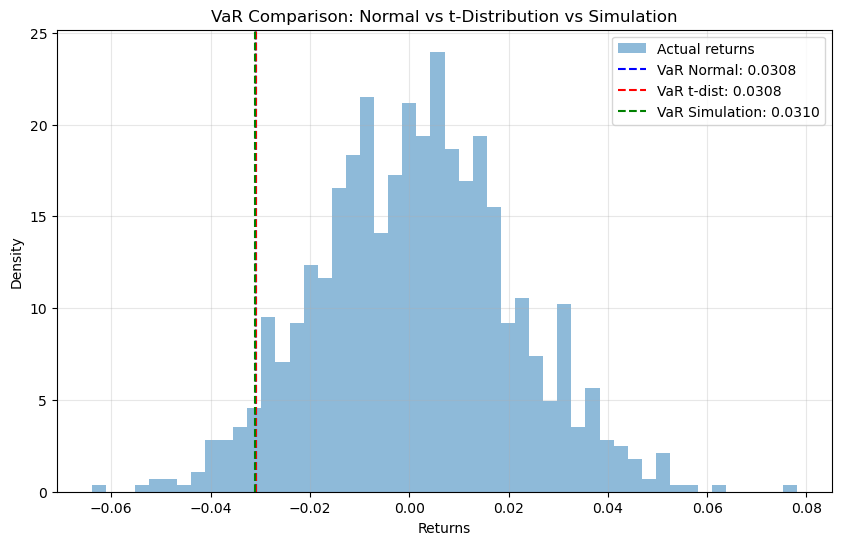

In [11]:
import numpy as np
import pandas as pd
from scipy import stats

# Generate sample returns data
np.random.seed(42)
returns = np.random.normal(0.001, 0.02, 1000)  # μ=0.1%, σ=2%

print("Sample statistics:")
print(f"Mean: {returns.mean():.6f}")
print(f"Std: {returns.std():.6f}")

# Method 1: VaR from Normal distribution
mu = returns.mean()
sigma = returns.std(ddof=1)

var_normal_abs = -stats.norm.ppf(0.05, mu, sigma)
var_normal_rel = -stats.norm.ppf(0.05, 0, sigma)

print("\n[Method 1] VaR from Normal Distribution (95% confidence):")
print(f"VaR Absolute: {var_normal_abs:.6f}")
print(f"VaR Relative: {var_normal_rel:.6f}")

# Method 2: VaR from t-distribution (heavier tails)
params = stats.t.fit(returns)
nu, mu_t, sigma_t = params[0], params[1], params[2]

var_t_abs = -stats.t.ppf(0.05, nu, mu_t, sigma_t)
var_t_rel = -stats.t.ppf(0.05, nu, 0, sigma_t)

print("\n[Method 2] VaR from t-Distribution (95% confidence):")
print(f"Degrees of freedom: {nu:.2f}")
print(f"VaR Absolute: {var_t_abs:.6f}")
print(f"VaR Relative: {var_t_rel:.6f}")

# Method 3: VaR from Simulation
np.random.seed(42)
sim_returns = stats.t.rvs(nu, mu_t, sigma_t, size=100000)

var_sim_abs = -np.percentile(sim_returns, 5)
var_sim_rel = -(np.percentile(sim_returns, 5) - mu_t)

print("\n[Method 3] VaR from Simulation (95% confidence, 100k draws):")
print(f"VaR Absolute: {var_sim_abs:.6f}")
print(f"VaR Relative: {var_sim_rel:.6f}")

# Compare all methods
print("\n=== Comparison ===")
print(f"Normal vs t-dist: {abs(var_normal_abs - var_t_abs):.6f}")
print(f"t-dist vs Simulation: {abs(var_t_abs - var_sim_abs):.6f}")

# Visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(returns, bins=50, alpha=0.5, label='Actual returns', density=True)
plt.axvline(-var_normal_abs, color='blue', linestyle='--', label=f'VaR Normal: {var_normal_abs:.4f}')
plt.axvline(-var_t_abs, color='red', linestyle='--', label=f'VaR t-dist: {var_t_abs:.4f}')
plt.axvline(-var_sim_abs, color='green', linestyle='--', label=f'VaR Simulation: {var_sim_abs:.4f}')
plt.xlabel('Returns')
plt.ylabel('Density')
plt.title('VaR Comparison: Normal vs t-Distribution vs Simulation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Key insights:**
- **Normal VaR** underestimates risk (assumes no fat tails)
- **t-distribution VaR** better captures tail risk (fatter tails)
- **Simulation VaR** most flexible, matches t-distribution closely

**In practice:** Use t-distribution or simulation for financial data (which has fat tails). Normal distribution is too optimistic about extreme losses.

**Limitations of VaR:**
- Doesn't tell you HOW BAD losses can be beyond VaR threshold
- Can be gamed (convex instruments)
- CVaR (Conditional VaR) addresses this by averaging losses beyond VaR

# Quiz 2: Exponentially Weighted Covaraince and VaR

In [ ]:
# Example: 
# Calculae the arithmetic returns of A and B. Using lambda = 0.94, calculate the exponentially weighted covariance matrix of A and B.  
# What is the exponentially weighted covariance matrix of A and B?

import numpy as np
import pandas as pd

# Load data
data = pd.read_csv('quiz2.csv')

# Calculate arithmetic returns
returns = data[['A', 'B']].pct_change().dropna()

# Exponentially weighted covariance with lambda = 0.94
lambda_decay = 0.94
n = len(returns)

# calculate exponential weights
weights = np.array([(1 - lambda_decay) * (lambda_decay ** i) for i in range(n)]) # equation: w_i = (1 - λ) * λ^i for i=0 to n-1, where i=0 is the most recent return and i=n-1 is the oldest return.
weights = weights[::-1]  # reverse so most recent is last
weights = weights / weights.sum()  # normalize

# weighted mean
weighted_mean = (returns * weights[:, np.newaxis]).sum(axis=0)

# weighted covariance
cov_matrix = np.zeros((2, 2))
for i in range(2):
    for j in range(2):
        dev_i = returns.iloc[:, i] - weighted_mean.iloc[i]
        dev_j = returns.iloc[:, j] - weighted_mean.iloc[j]
        cov_matrix[i, j] = (weights * dev_i * dev_j).sum()
        # mathematically: cov_ij = sum(w_k * (r_k_i - weighted_mean_i) * (r_k_j - weighted_mean_j)) for k=1 to n, where w_k is the weight for the k-th return, r_k_i is the return of asset i at time k, and weighted_mean_i is the exponentially weighted mean return of asset i.
  

print("Exponentially Weighted Covariance Matrix (λ=0.94):")
print(pd.DataFrame(cov_matrix, columns=['A', 'B'], index=['A', 'B']))


Exponentially Weighted Covariance Matrix (λ=0.94):
          A         B
A  0.000186  0.000098
B  0.000098  0.000223


In [ ]:
# example continued,

'''

Exponentially Weighted Covariance Matrix (λ=0.94):
          A         B
A  0.000186  0.000098
B  0.000098  0.000223

'''

# Given this exponentially weighted covariance, assume multivariate normality and 0 expectedv value, what is the VaR of A at alpha = 0.05?
# VaR for asset A at 95% confidence level
import scipy.stats as stats
var_A = -np.sqrt(cov_matrix[0, 0]) * stats.norm.ppf(0.05) # VaR = -σ * z, where σ is the standard deviation (sqrt of variance) and z is the z-score for the 5th percentile of the standard normal distribution.
# mathematically: VaR_A = -sqrt(cov_AA) * z_0.05, where cov_AA is the variance of asset A from the covariance matrix, and z_0.05 is the z-score corresponding to the 5% quantile of the standard normal distribution (approximately -1.645).
# ppf "aka inverse cdf, aka quantile function" gives the z-score for the specified percentile (0.05 in this case). Since we want the VaR, which is a positive number representing the loss, we take the negative of that z-score.
print(f"VaR of A at 95% confidence: {var_A:.6f}")

VaR of A at 95% confidence: 0.022407


In [ ]:
# Fit a t-distribution to the returns of B. Assume 0 expected value. What is the VaR of B at alpha = 0.05 using the t-distribution fit?
# Fit t-distribution to returns of B
params = stats.t.fit(returns['B'], floc=0)  # fix location
nu, loc, scale = params # nu is degrees of freedom, loc is location (mean), scale is scale (std deviation)
var_B_t = -scale * stats.t.ppf(0.05, nu)
print(f"VaR of B at 95% confidence (t-distribution): {var_B_t:.6f}")

VaR of B at 95% confidence (t-distribution): 0.029032


## **Quick Review: Exponentially Weighted Covariance & VaR**

### **1. Exponentially Weighted Covariance (λ=0.94)**

**Concept:** Recent data matters more than old data. Give exponentially decaying weights.

**Math:**
```
Weight for i-th period ago: w_i = (1-λ)·λ^i
Then normalize: w_i = w_i / Σw_i
```

**Formula:**
```
Cov(X,Y) = Σ w_i · (x_i - μ_x) · (y_i - μ_y)
```

**Code pattern:**
```python
weights = [(1-λ) * λ^i for i in range(n)]
weights = weights[::-1]  # reverse (most recent last)
weights = weights / weights.sum()  # normalize

weighted_mean = Σ(returns * weights)
cov[i,j] = Σ weights · (dev_i) · (dev_j)
```

---

### **2. VaR from Normal Distribution**

**Concept:** Assuming returns ~ N(μ, σ²), find 5th percentile (95% confidence).

**Math:**
```
VaR_0.05 = -(μ + σ·z_0.05)
where z_0.05 = -1.645
```

**If μ=0 (assumed):**
```
VaR = -σ·z_0.05 = σ·1.645
```

**Code:**
```python
sigma = np.sqrt(variance)
var = -stats.norm.ppf(0.05, 0, sigma)
# or equivalently
var = sigma * 1.645
```

---

### **3. VaR from t-Distribution**

**Concept:** t-distribution has **fatter tails** than normal (captures extreme events better).

**Math:**
```
VaR_0.05 = -(μ + σ·t_0.05,ν)
where t_0.05,ν depends on degrees of freedom ν
```

**Key:** Must fit the t-distribution to data to get ν (df) and σ (scale).

**Code (correct way - force μ=0):**
```python
params = stats.t.fit(returns, floc=0)  # force location=0
nu, loc, scale = params
var = -scale * stats.t.ppf(0.05, nu)
```

**Why floc=0?** Forces the fit to assume zero mean, so scale is calibrated correctly.

---

### **Key Differences:**

| Method | Tail Behavior | Use Case |
|--------|---------------|----------|
| Normal | Thin tails | Fast, underestimates risk |
| t-distribution | Fat tails | More realistic for finance |

**t-distribution always gives higher VaR** because it accounts for extreme events better.